# Calibrated Risk Thresholds

This notebook derives development-stage Low, Medium, High, and Critical boundaries on the **sigmoid-calibrated model score scale**. It does not reuse notebook 03's uncalibrated numerical thresholds. Threshold selection uses training out-of-fold (OOF) predictions only; the holdout is evaluated only after the boundaries are frozen.

In [1]:
import json
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.metrics import (confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.features import RAW_FEATURES
from src.pipeline import build_production_model

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

## 1. Reproduce the production score scale

Only the six allowed raw inputs enter the reusable production estimator. Feature engineering, preprocessing, Gradient Boosting, and five-fold sigmoid calibration all remain inside the imported production architecture. Identifiers, the target, and failure-mode labels cannot enter the predictive matrix.

In [2]:
df = pd.read_csv("../data/raw/ai4i2020.csv")
target_column = "Machine failure"
forbidden_inputs = ["UDI", "Product ID", target_column, "TWF", "HDF", "PWF", "OSF", "RNF"]
X = df.loc[:, RAW_FEATURES].copy()
y = df[target_column].copy()
assert not set(forbidden_inputs).intersection(X.columns)

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
split_summary = pd.DataFrame({
    "Observations": [len(y_train), len(y_holdout)],
    "Failures": [int(y_train.sum()), int(y_holdout.sum())],
    "Failure rate": [y_train.mean(), y_holdout.mean()],
}, index=["Training", "Holdout"])
display(split_summary.style.format({"Failure rate": "{:.2%}"}))

,Observations,Failures,Failure rate
Training,8000,271,3.39%
Holdout,2000,68,3.40%


## 2. Leakage-safe calibrated OOF scores

The outer five-fold split below generates exactly one score for each training observation. In each outer fold, `build_production_model()` performs its own inner five-fold sigmoid calibration using only the outer-fold training observations. Therefore, an observation is excluded from feature/preprocessing fitting, classifier fitting, and calibration mapping when its OOF score is produced. Holdout data is not involved.

In [3]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_calibrated_scores = cross_val_predict(
    build_production_model(), X_train, y_train, cv=outer_cv,
    method="predict_proba"
)[:, 1]
assert len(oof_calibrated_scores) == len(y_train)
assert np.all((oof_calibrated_scores >= 0) & (oof_calibrated_scores <= 1))

## 3. OOF calibrated-score distributions

Density-normalized distributions prevent the much larger non-failure class from visually overwhelming the failures. Separation supports ranking, while overlap identifies observations for which any threshold policy must trade missed failures against additional alerts.

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
actual_failure,,,,,,,,,,,
Actual non-failure,7729.0,0.007430,0.03015,0.001036,0.001755,0.002056,0.003733,0.007163,0.025536,0.120026,0.865434
Actual failure,271.0,0.789648,0.33352,0.001392,0.888261,0.937215,0.972910,0.984148,0.995097,0.998609,0.999891


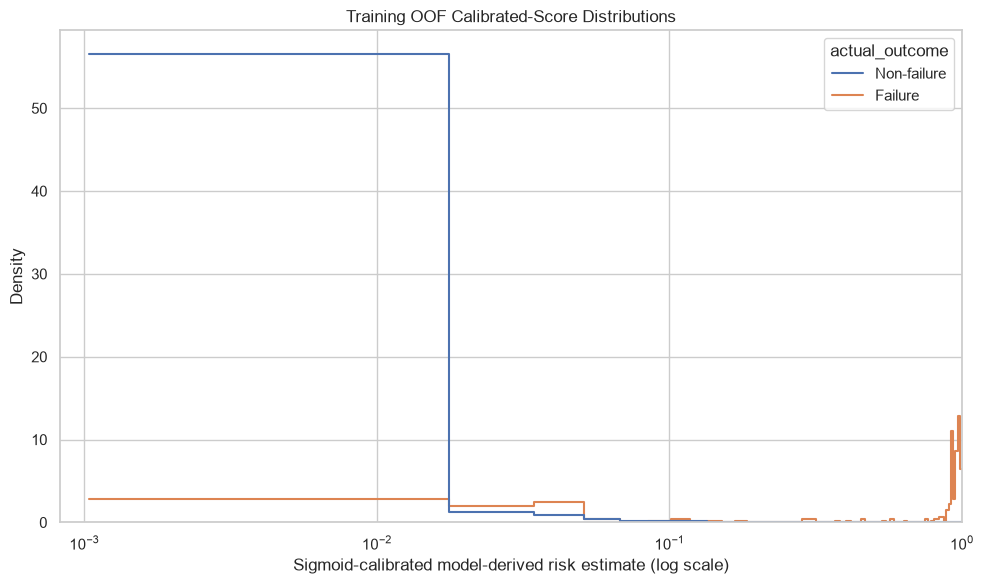

In [4]:
oof_results = pd.DataFrame({
    "actual_failure": y_train.to_numpy(),
    "calibrated_risk_estimate": oof_calibrated_scores,
})
oof_distribution_summary = (
    oof_results.groupby("actual_failure")["calibrated_risk_estimate"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .rename(index={0: "Actual non-failure", 1: "Actual failure"})
)
display(oof_distribution_summary)

oof_plot = oof_results.assign(
    actual_outcome=oof_results.actual_failure.map({0: "Non-failure", 1: "Failure"})
)
plt.figure(figsize=(10, 6))
sns.histplot(data=oof_plot, x="calibrated_risk_estimate", hue="actual_outcome",
             bins=60, stat="density", common_norm=False, element="step", fill=False)
plt.xscale("log"); plt.xlim(max(oof_calibrated_scores.min() * 0.8, 1e-5), 1)
plt.xlabel("Sigmoid-calibrated model-derived risk estimate (log scale)")
plt.title("Training OOF Calibrated-Score Distributions")
plt.tight_layout(); plt.show()

## 4. Precision–recall threshold selection

The policy objectives match notebook 03 for conceptual comparability: Medium maximizes precision subject to recall ≥ 90%; High maximizes recall subject to precision ≥ 90%; Critical maximizes recall subject to precision ≥ 95%. The objectives are provisional operating assumptions—not universal safety standards. Exact boundaries are derived from calibrated training OOF scores.

In [5]:
def derive_policy_thresholds(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    table = pd.DataFrame({
        "threshold": thresholds, "precision": precision[:-1], "recall": recall[:-1]
    })
    table["f1"] = 2 * table.precision * table.recall / (table.precision + table.recall).replace(0, np.nan)
    medium = table[table.recall >= 0.90].sort_values(
        ["precision", "threshold"], ascending=[False, False]).iloc[0]
    high = table[table.precision >= 0.90].sort_values(
        ["recall", "threshold"], ascending=[False, True]).iloc[0]
    critical = table[table.precision >= 0.95].sort_values(
        ["recall", "threshold"], ascending=[False, True]).iloc[0]
    return table, {"Medium": medium, "High": high, "Critical": critical}

threshold_analysis, selected_rows = derive_policy_thresholds(y_train, oof_calibrated_scores)
medium_threshold = float(selected_rows["Medium"].threshold)
high_threshold = float(selected_rows["High"].threshold)
critical_threshold = float(selected_rows["Critical"].threshold)
assert 0 < medium_threshold < high_threshold < critical_threshold < 1

selected_thresholds = pd.DataFrame({
    "Policy objective": ["Max precision with recall ≥ 90%",
                         "Max recall with precision ≥ 90%",
                         "Max recall with precision ≥ 95%"],
    "Threshold (0–1)": [medium_threshold, high_threshold, critical_threshold],
    "Display score (0–100)": [100*medium_threshold, 100*high_threshold, 100*critical_threshold],
    "OOF precision": [selected_rows[x].precision for x in ["Medium", "High", "Critical"]],
    "OOF recall": [selected_rows[x].recall for x in ["Medium", "High", "Critical"]],
}).set_index(pd.Index(["Medium", "High", "Critical"], name="Boundary"))
display(selected_thresholds.style.format({
    "Threshold (0–1)": "{:.6f}", "Display score (0–100)": "{:.2f}",
    "OOF precision": "{:.3f}", "OOF recall": "{:.3f}"
}))

,Policy objective,Threshold (0–1),Display score (0–100),OOF precision,OOF recall
Boundary,,,,,
Medium,Max precision with recall ≥ 90%,0.042688,4.27,0.509,0.900
High,Max recall with precision ≥ 90%,0.238910,23.89,0.902,0.852
Critical,Max recall with precision ≥ 95%,0.408313,40.83,0.954,0.834


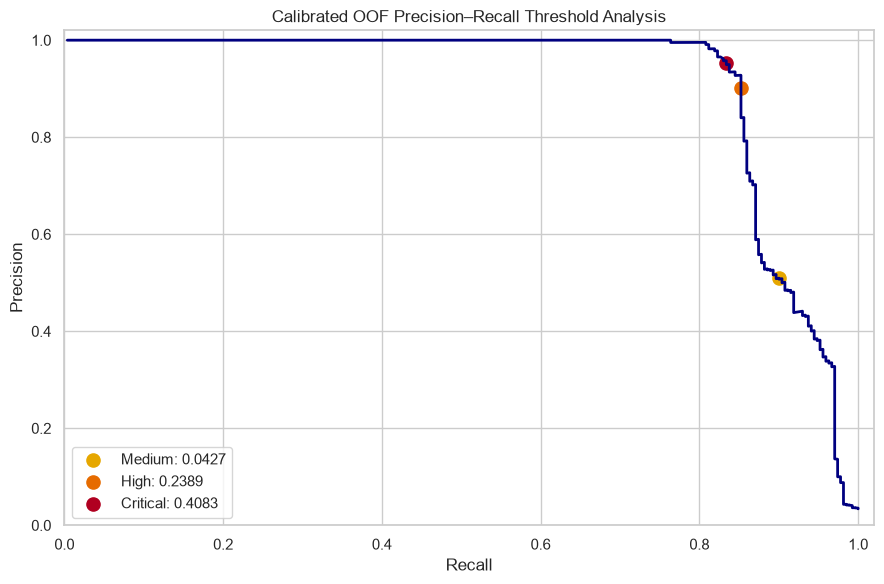

In [6]:
plt.figure(figsize=(9, 6))
plt.plot(threshold_analysis.recall, threshold_analysis.precision, color="navy", linewidth=2)
for name, color in zip(["Medium", "High", "Critical"], ["#e6a700", "#e66b00", "#b00020"]):
    row = selected_rows[name]
    plt.scatter(row.recall, row.precision, s=90, color=color,
                label=f"{name}: {row.threshold:.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Calibrated OOF Precision–Recall Threshold Analysis")
plt.xlim(0, 1.02); plt.ylim(0, 1.02); plt.legend(); plt.tight_layout(); plt.show()

## 5. Reusable categorization and OOF category profile

`categorize_calibrated_score` expects a scalar on the internal **0–1 calibrated score scale**. Multiplication by 100 is display formatting only. Boundaries use left-inclusive intervals: a score exactly at a boundary enters the higher-risk category.

In [7]:
category_order = ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]
risk_bins = [-np.inf, medium_threshold, high_threshold, critical_threshold, np.inf]

def categorize_calibrated_score(score):
    if pd.isna(score) or not 0 <= score <= 1:
        raise ValueError("Calibrated score must be a non-missing value on the 0–1 scale.")
    if score < medium_threshold:
        return "Low Risk"
    if score < high_threshold:
        return "Medium Risk"
    if score < critical_threshold:
        return "High Risk"
    return "Critical Risk"

oof_results["risk_category"] = pd.Categorical(
    [categorize_calibrated_score(score) for score in oof_calibrated_scores],
    categories=category_order, ordered=True
)
oof_category_profile = oof_results.groupby("risk_category", observed=False).agg(
    observations=("actual_failure", "size"),
    actual_failures=("actual_failure", "sum"),
    actual_failure_rate=("actual_failure", "mean"),
).reindex(category_order)
oof_category_profile["percentage"] = oof_category_profile.observations / len(oof_results)
oof_category_profile = oof_category_profile[["observations", "percentage", "actual_failures", "actual_failure_rate"]]
assert oof_category_profile.observations.sum() == len(y_train)
assert oof_category_profile.actual_failures.sum() == int(y_train.sum())
display(oof_category_profile.style.format({"percentage": "{:.2%}", "actual_failure_rate": "{:.2%}"}))

,observations,percentage,actual_failures,actual_failure_rate
risk_category,,,,
Low Risk,7521,94.01%,27,0.36%
Medium Risk,223,2.79%,13,5.83%
High Risk,19,0.24%,5,26.32%
Critical Risk,237,2.96%,226,95.36%


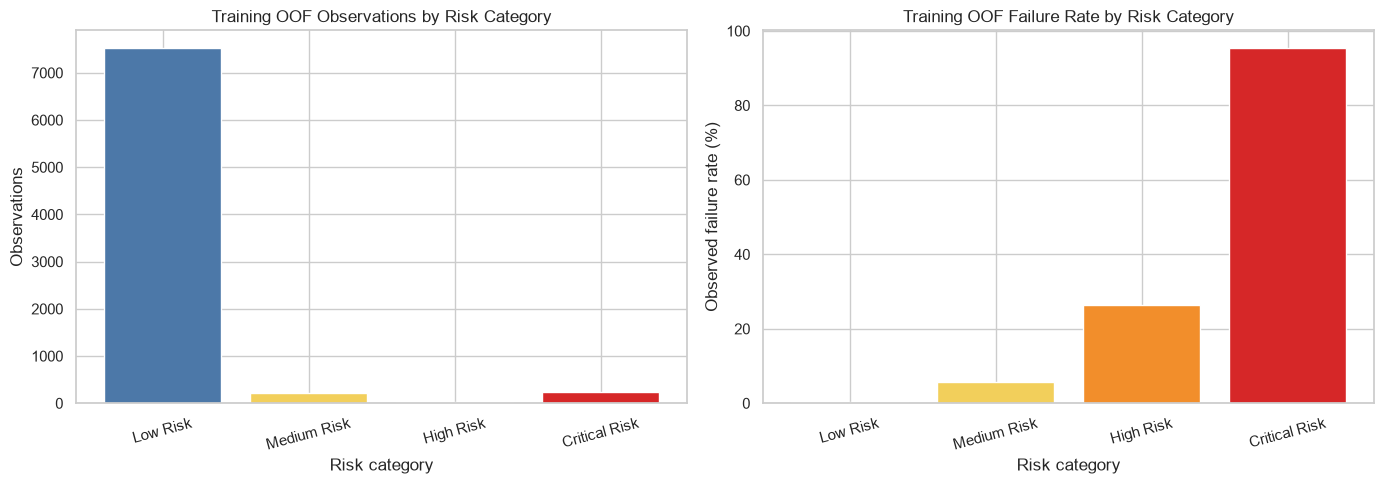

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#4c78a8", "#f2cf5b", "#f28e2b", "#d62728"]
axes[0].bar(category_order, oof_category_profile.observations, color=colors)
axes[0].set(title="Training OOF Observations by Risk Category", xlabel="Risk category", ylabel="Observations")
axes[1].bar(category_order, 100*oof_category_profile.actual_failure_rate, color=colors)
axes[1].set(title="Training OOF Failure Rate by Risk Category", xlabel="Risk category", ylabel="Observed failure rate (%)")
for axis in axes: axis.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

## 6. Lightweight threshold-stability check

Two additional shuffled outer five-fold runs test sensitivity to fold assignment. This is useful development evidence, but three runs are not confidence intervals and do not replace repeated-CV or bootstrap uncertainty analysis. Each run still uses nested, training-only calibration.

In [9]:
stability_rows = [{"Outer CV seed": 42, "Medium": medium_threshold,
                   "High": high_threshold, "Critical": critical_threshold}]
for seed in [52, 62]:
    repeated_scores = cross_val_predict(
        build_production_model(), X_train, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
        method="predict_proba"
    )[:, 1]
    _, repeated_selection = derive_policy_thresholds(y_train, repeated_scores)
    stability_rows.append({"Outer CV seed": seed, **{
        name: float(repeated_selection[name].threshold)
        for name in ["Medium", "High", "Critical"]
    }})
stability_runs = pd.DataFrame(stability_rows).set_index("Outer CV seed")
stability_summary = stability_runs.agg(["median", "min", "max"]).T
stability_summary["range"] = stability_summary["max"] - stability_summary["min"]
display(stability_runs.style.format("{:.6f}"))
display(stability_summary.style.format("{:.6f}"))

,Medium,High,Critical
Outer CV seed,,,
42,0.042688,0.238910,0.408313
52,0.050442,0.247578,0.398383
62,0.051324,0.232383,0.374355


,median,min,max,range
Medium,0.050442,0.042688,0.051324,0.008636
High,0.238910,0.232383,0.247578,0.015196
Critical,0.398383,0.374355,0.408313,0.033959


## 7. Freeze thresholds and write the development artifact

Ordering is validated before serialization. The JSON contains only calibrated thresholds derived from training OOF scores; it contains no uncalibrated notebook 03 values and no absolute filesystem paths.

In [10]:
assert medium_threshold < high_threshold < critical_threshold
threshold_artifact = {
    "threshold_version": "1.0.0",
    "score_scale": "0-1 sigmoid-calibrated model-derived risk estimate",
    "calibration_method": "sigmoid",
    "thresholds": {"medium": medium_threshold, "high": high_threshold, "critical": critical_threshold},
    "policy_objectives": {
        "medium": "highest precision while recall >= 0.90",
        "high": "highest recall while precision >= 0.90",
        "critical": "highest recall while precision >= 0.95",
    },
    "source_notebook": "notebooks/05_calibrated_risk_thresholds.ipynb",
    "development_dataset": "AI4I 2020 Predictive Maintenance Dataset",
    "methodological_warnings": [
        "Development-stage operational thresholds, not validated industrial safety limits.",
        "Derived from approximately 271 positive training observations and one primary five-fold OOF run.",
        "Policy objectives are provisional; no bootstrap confidence intervals are available.",
        "Validate on an independent project-level lockbox before backend integration.",
    ],
}
threshold_artifact_path = PROJECT_ROOT / "models" / "factorymind_failure_risk_thresholds_v1.json"
threshold_artifact_path.parent.mkdir(parents=True, exist_ok=True)
threshold_artifact_path.write_text(json.dumps(threshold_artifact, indent=2) + "\n", encoding="utf-8")
print(threshold_artifact_path.relative_to(PROJECT_ROOT))

models/factorymind_failure_risk_thresholds_v1.json


## 8. Frozen-threshold holdout evaluation

Only now—after threshold selection, validation, and freezing—is the production estimator fitted on all training observations and applied to the holdout. Holdout labels evaluate the frozen policies and never revise them.

In [11]:
production_model = build_production_model().fit(X_train, y_train)
holdout_scores = production_model.predict_proba(X_holdout)[:, 1]

policy_rows = []
for policy, threshold in {"Medium or higher": medium_threshold,
                          "High or higher": high_threshold,
                          "Critical only": critical_threshold,
                          "Standard 0.50": 0.50}.items():
    predicted = (holdout_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_holdout, predicted).ravel()
    policy_rows.append({"Policy": policy, "Threshold": threshold,
                        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
                        "Precision": precision_score(y_holdout, predicted, zero_division=0),
                        "Recall": recall_score(y_holdout, predicted),
                        "F1": f1_score(y_holdout, predicted)})
holdout_policy_metrics = pd.DataFrame(policy_rows).set_index("Policy")
display(holdout_policy_metrics.style.format({"Threshold": "{:.6f}",
    "Precision": "{:.3f}", "Recall": "{:.3f}", "F1": "{:.3f}"}))

,Threshold,TN,FP,FN,TP,Precision,Recall,F1
Policy,,,,,,,,
Medium or higher,0.042688,1856,76,4,64,0.457,0.941,0.615
High or higher,0.238910,1928,4,10,58,0.935,0.853,0.892
Critical only,0.408313,1930,2,13,55,0.965,0.809,0.880
Standard 0.50,0.500000,1932,0,13,55,1.000,0.809,0.894


## 9. Holdout category profile

Category counts describe observations, not persistent machines. Categories with fewer than 20 holdout observations are explicitly flagged because their observed failure rates are statistically unstable.

In [12]:
holdout_results = pd.DataFrame({"actual_failure": y_holdout.to_numpy(),
                                "calibrated_risk_estimate": holdout_scores})
holdout_results["risk_category"] = pd.Categorical(
    [categorize_calibrated_score(score) for score in holdout_scores],
    categories=category_order, ordered=True
)
holdout_profile = holdout_results.groupby("risk_category", observed=False).agg(
    observations=("actual_failure", "size"), actual_failures=("actual_failure", "sum"),
    observed_failure_rate=("actual_failure", "mean"),
).reindex(category_order)
holdout_profile["holdout_percentage"] = holdout_profile.observations / len(holdout_results)
holdout_profile["small_sample_warning"] = np.where(holdout_profile.observations < 20, "CAUTION: n < 20", "")
holdout_profile = holdout_profile[["observations", "holdout_percentage", "actual_failures",
                                   "observed_failure_rate", "small_sample_warning"]]
assert holdout_profile.observations.sum() == len(y_holdout) == 2000
assert holdout_profile.actual_failures.sum() == int(y_holdout.sum()) == 68
assert holdout_profile.observed_failure_rate.is_monotonic_increasing
display(holdout_profile.style.format({"holdout_percentage": "{:.2%}",
                                       "observed_failure_rate": "{:.2%}"}))

,observations,holdout_percentage,actual_failures,observed_failure_rate,small_sample_warning
risk_category,,,,,
Low Risk,1860,93.00%,4,0.22%,
Medium Risk,78,3.90%,6,7.69%,
High Risk,5,0.25%,3,60.00%,CAUTION: n < 20
Critical Risk,57,2.85%,55,96.49%,


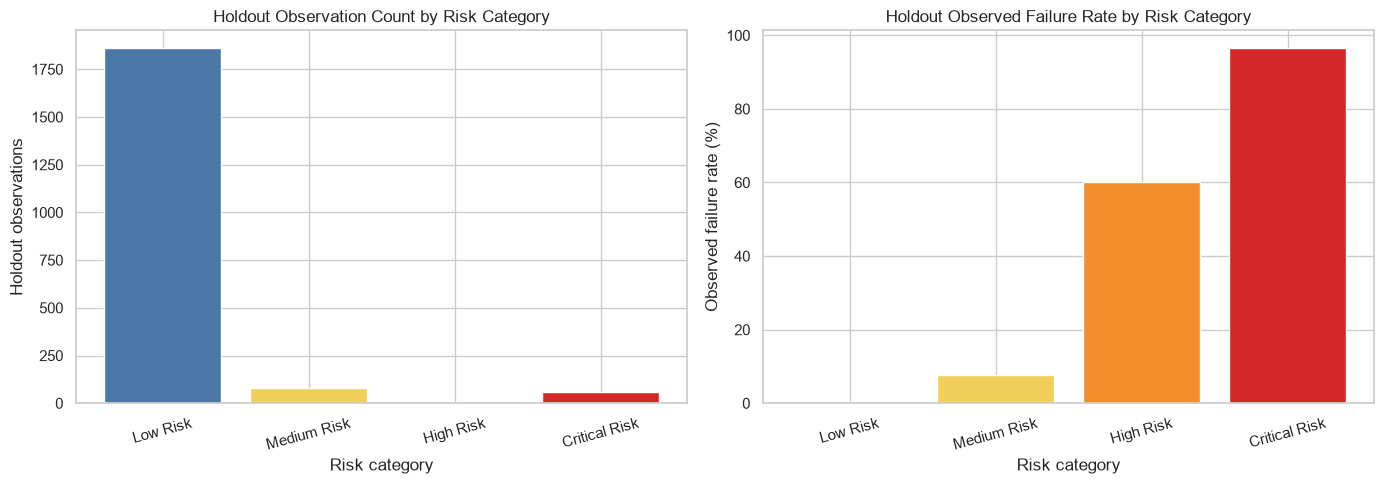

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(category_order, holdout_profile.observations, color=colors)
axes[0].set(title="Holdout Observation Count by Risk Category", xlabel="Risk category", ylabel="Holdout observations")
axes[1].bar(category_order, 100*holdout_profile.observed_failure_rate, color=colors)
axes[1].set(title="Holdout Observed Failure Rate by Risk Category", xlabel="Risk category", ylabel="Observed failure rate (%)")
for axis in axes: axis.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

## 10. Conceptual comparison with notebook 03

Numerical boundary values are not compared because calibration changes the score scale. Instead, the operational outcomes below compare the uncalibrated notebook 03 policies with the calibrated policies. Medium+ becomes broader on this holdout, reducing false negatives from 7 to 4 while increasing false positives from 65 to 76. High+ and Critical-only behavior remains very similar. This comparison is descriptive because the same development holdout has been repeatedly examined.

In [14]:
notebook03_reference = pd.DataFrame({
    "Policy": ["Medium or higher", "High or higher", "Critical only"],
    "Uncalibrated precision": [0.484127, 0.920635, 0.964912],
    "Uncalibrated recall": [0.897059, 0.852941, 0.808824],
    "Uncalibrated FP": [65, 5, 2], "Uncalibrated FN": [7, 10, 13],
}).set_index("Policy")
calibrated_comparison = holdout_policy_metrics.loc[notebook03_reference.index, ["Precision", "Recall", "FP", "FN"]].rename(
    columns=lambda column: "Calibrated " + column)
display(notebook03_reference.join(calibrated_comparison).style.format({
    column: "{:.3f}" for column in ["Uncalibrated precision", "Uncalibrated recall",
                                          "Calibrated Precision", "Calibrated Recall"]
}))

,Uncalibrated precision,Uncalibrated recall,Uncalibrated FP,Uncalibrated FN,Calibrated Precision,Calibrated Recall,Calibrated FP,Calibrated FN
Policy,,,,,,,,
Medium or higher,0.484,0.897,65,7,0.457,0.941,76,4
High or higher,0.921,0.853,5,10,0.935,0.853,4,10
Critical only,0.965,0.809,2,13,0.965,0.809,2,13


## Calibrated Risk Threshold Conclusions

In [15]:
display(Markdown(f"""
The calibrated development boundaries are **{medium_threshold:.6f} ({100*medium_threshold:.2f}/100)** for Medium, **{high_threshold:.6f} ({100*high_threshold:.2f}/100)** for High, and **{critical_threshold:.6f} ({100*critical_threshold:.2f}/100)** for Critical. Their respective provisional objectives are recall ≥ 90%, precision ≥ 90%, and precision ≥ 95% on calibrated training OOF scores. OOF precision/recall were **{selected_rows['Medium'].precision:.3f}/{selected_rows['Medium'].recall:.3f}**, **{selected_rows['High'].precision:.3f}/{selected_rows['High'].recall:.3f}**, and **{selected_rows['Critical'].precision:.3f}/{selected_rows['Critical'].recall:.3f}**.

On holdout data, Medium+ produced precision/recall **{holdout_policy_metrics.loc['Medium or higher','Precision']:.3f}/{holdout_policy_metrics.loc['Medium or higher','Recall']:.3f}**, High+ **{holdout_policy_metrics.loc['High or higher','Precision']:.3f}/{holdout_policy_metrics.loc['High or higher','Recall']:.3f}**, and Critical-only **{holdout_policy_metrics.loc['Critical only','Precision']:.3f}/{holdout_policy_metrics.loc['Critical only','Recall']:.3f}**. Observed failure risk increases monotonically across categories, but the High category has only **{holdout_profile.loc['High Risk','observations']}** holdout observations and is unstable.

Across three outer-CV seeds, threshold ranges were Medium **{stability_summary.loc['Medium','min']:.4f}–{stability_summary.loc['Medium','max']:.4f}**, High **{stability_summary.loc['High','min']:.4f}–{stability_summary.loc['High','max']:.4f}**, and Critical **{stability_summary.loc['Critical','min']:.4f}–{stability_summary.loc['Critical','max']:.4f}**. This supports development use but not an industrial safety claim. The approximately **{int(y_train.sum())}** positive training observations, one primary five-fold OOF run, lack of bootstrap confidence intervals, provisional policies, synthetic dataset, and reused holdout remain important limitations.

These thresholds are suitable for controlled backend prototyping only if returned as development-stage calibrated risk categories with versioned metadata and no safety guarantee. Independent lockbox validation, cost-based policy review, and stronger stability analysis should precede production integration.
"""))


The calibrated development boundaries are **0.042688 (4.27/100)** for Medium, **0.238910 (23.89/100)** for High, and **0.408313 (40.83/100)** for Critical. Their respective provisional objectives are recall ≥ 90%, precision ≥ 90%, and precision ≥ 95% on calibrated training OOF scores. OOF precision/recall were **0.509/0.900**, **0.902/0.852**, and **0.954/0.834**.

On holdout data, Medium+ produced precision/recall **0.457/0.941**, High+ **0.935/0.853**, and Critical-only **0.965/0.809**. Observed failure risk increases monotonically across categories, but the High category has only **5** holdout observations and is unstable.

Across three outer-CV seeds, threshold ranges were Medium **0.0427–0.0513**, High **0.2324–0.2476**, and Critical **0.3744–0.4083**. This supports development use but not an industrial safety claim. The approximately **271** positive training observations, one primary five-fold OOF run, lack of bootstrap confidence intervals, provisional policies, synthetic dataset, and reused holdout remain important limitations.

These thresholds are suitable for controlled backend prototyping only if returned as development-stage calibrated risk categories with versioned metadata and no safety guarantee. Independent lockbox validation, cost-based policy review, and stronger stability analysis should precede production integration.
